# K-Nearest Neighbors (KNN)
K-Nearest Neighbors (KNN) is een eenvoudig en intuïtief machine learning-algoritme dat wordt gebruikt voor zowel classificatie- als regressietaken. Het principe achter KNN is gebaseerd op het idee dat vergelijkbare gegevenspunten zich in de buurt van elkaar bevinden in de feature-ruimte. Bij het classificeren van een nieuw gegevenspunt kijkt KNN naar de 'k' dichtstbijzijnde buren (gegevenspunten) in de trainingsset en wijst het nieuwe punt toe aan de klasse die het meest voorkomt onder deze buren.

In [ ]:
import sys
import os
import re
import h5py
import pandas as pd
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from scipy.ndimage import median_filter
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

# Add the parent directory (project root) to Python path
project_root = os.path.abspath('..')  # Go up one level from current notebook
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from libs_generic_functions import LibsDataLoader, LibsDataPreprocessor
from baseline_correction_functions import BaselineCorrector, analyze_correction_quality, print_quality_report

Voordat we KNN goed kunnen gebruiken moeten wij dimensionaliteitsreductie toepassen. Dit is omdat KNN veel moeite heeft met "The curse of dimensionality", oftewel dimensionaliteitsvloek. De data bestaat namelijk uit een set van (51453, 8188). KNN zal hier niet goed kunnen classificeren. 

Hierbij zullen wij LDA en PCA testen

In [ ]:
%%time
data_loader = LibsDataLoader(data_directory='../data/')
df_individual = data_loader.load_all_measurements()

In [ ]:
%%time
Preprocessor = LibsDataPreprocessor()
df_individual = Preprocessor.prepare_ml_data(df_individual) 

In [ ]:
X_train, X_test, y_train, y_test = Preprocessor.split_data(df_individual[0], df_individual[1], test_size=0.2, random_state=42)

Splitting data into train and test sets...
Training set shape: (41162, 8188)
Test set shape: (10291, 8188)
Standardizing features...
Data preprocessing completed successfully!
Data preprocessing completed successfully!


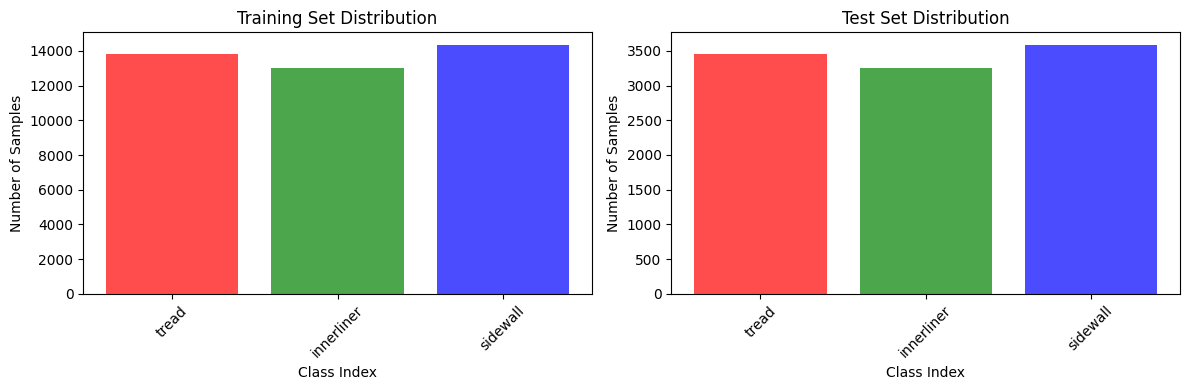

In [ ]:
# Train-Test Split and Preprocessing
print("Splitting data into train and test sets...")

# Encode labels to numeric values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df_individual[1])

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# Feature standardization
print("Standardizing features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing completed successfully!")

# Display train/test distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Training set distribution
train_unique, train_counts = np.unique(y_train, return_counts=True)
ax1.bar(range(len(train_unique)), train_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax1.set_title('Training Set Distribution')
ax1.set_xlabel('Class Index')
ax1.set_ylabel('Number of Samples')
ax1.set_xticks(range(len(train_unique)))
ax1.set_xticklabels(("tread", "innerliner", "sidewall"), rotation=45)

# Test set distribution  
test_unique, test_counts = np.unique(y_test, return_counts=True)
ax2.bar(range(len(test_unique)), test_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax2.set_title('Test Set Distribution')
ax2.set_xlabel('Class Index')
ax2.set_ylabel('Number of Samples')
ax2.set_xticks(range(len(test_unique)))
ax2.set_xticklabels(("tread", "innerliner", "sidewall"), rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
%%time
import time

# Import the baseline correction module

print("Baseline correction functions imported successfully!")

# Create baseline corrector instance
corrector = BaselineCorrector()

# Apply Hybrid 4S+AsLS baseline correction to training and test data
print(f"\nApplying Hybrid 4S+AsLS baseline correction to LIBS data...")
print(f"Original training data shape: {X_train.shape}")
print(f"Original test data shape: {X_test.shape}")

start_time = time.time()

# Apply baseline correction to training data
print("Correcting training data...")
X_train_corrected = corrector.apply_correction_batch(
    X_train, 
    method='hybrid',
    batch_size=100,
    window_length=51, 
    polyorder=3, 
    als_lam=1e4, 
    als_p=0.01
)

# Apply baseline correction to test data  
print("Correcting test data...")
X_test_corrected = corrector.apply_correction_batch(
    X_test,
    method='hybrid',
    batch_size=100,
    window_length=51,
    polyorder=3,
    als_lam=1e4,
    als_p=0.01
)

correction_time = time.time() - start_time

# Convert back to DataFrames with original column names
X_train_corrected_df = pd.DataFrame(X_train_corrected, 
                                   columns=X_train.columns, 
                                   index=X_train.index)
X_test_corrected_df = pd.DataFrame(X_test_corrected, 
                                  columns=X_test.columns, 
                                  index=X_test.index)

print(f"✅ Baseline correction completed in {correction_time:.1f} seconds")
print(f"Corrected training data shape: {X_train_corrected_df.shape}")
print(f"Corrected test data shape: {X_test_corrected_df.shape}")

# Quality analysis using the new functions
quality_metrics = analyze_correction_quality(
    X_train, 
    X_train_corrected, 
    class_labels=y_train.values
)
print_quality_report(quality_metrics)

# Visualization of baseline correction effect
print(f"\nCreating baseline correction visualization...")

# Select a representative spectrum for visualization
sample_idx = 42  # Use a fixed index for reproducibility
sample_spectrum_orig = X_train.iloc[sample_idx].values
wavelengths = np.array([float(col) for col in X_train.columns])

# Use the new visualization method
corrector.visualize_correction(
    sample_spectrum_orig,
    wavelengths=wavelengths,
    method='hybrid',
    window_length=51,
    polyorder=3,
    als_lam=1e4,
    als_p=0.01
)

# Additional class-wise intensity analysis
class_stats_orig = []
class_stats_corr = []
classes = y_train.unique()

for cls in classes:
    cls_mask = y_train == cls
    orig_mean = np.mean(X_train[cls_mask].values)
    corr_mean = np.mean(X_train_corrected[cls_mask])
    class_stats_orig.append(orig_mean)
    class_stats_corr.append(corr_mean)

# Create additional class comparison visualization
plt.figure(figsize=(10, 6))
x_pos = np.arange(len(classes))
width = 0.35

plt.bar(x_pos - width/2, class_stats_orig, width, label='Original', alpha=0.7, color='lightblue')
plt.bar(x_pos + width/2, class_stats_corr, width, label='Baseline Corrected', alpha=0.7, color='lightgreen')
plt.title('Mean Intensity by Class - Before vs After Baseline Correction')
plt.xlabel('Tire Component')
plt.ylabel('Mean Intensity')
plt.xticks(x_pos, classes)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n🎯 Ready for Naive Bayes analysis with baseline-corrected data!")
print(f"   • Applied: Hybrid 4S+AsLS baseline correction")
print(f"   • Processing time: {correction_time:.1f} seconds")
print(f"   • Training samples: {len(X_train_corrected_df):,}")
print(f"   • Test samples: {len(X_test_corrected_df):,}")
print(f"   • Features: {X_train_corrected_df.shape[1]}")

# Update the data variables to use baseline-corrected versions
print(f"\nUpdating data variables to use baseline-corrected spectra...")
X_train_original = X_train_corrected_df.copy()
X_test_original = X_test_corrected_df.copy()

print(f"\n💡 Baseline Correction Summary:")
print(f"   • Method: Hybrid 4S Peak Filling + AsLS")
print(f"   • Quality report shows statistical changes")
print(f"   • Visualization confirms proper baseline removal")
print(f"   • Data ready for machine learning analysis")

1. KNN Classification on Original Features
Finding optimal k parameter...
Optimal k: 4
Optimal k: 4


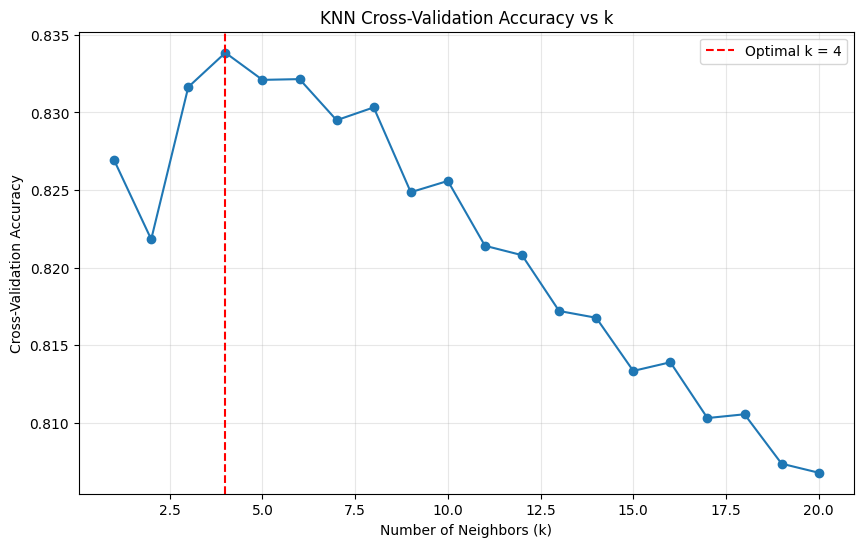


KNN Accuracy on Original Features: 0.8477

Classification Report (Original Features):
              precision    recall  f1-score   support

  innerliner       0.85      0.90      0.88      3452
    sidewall       0.83      0.78      0.81      3252
       tread       0.85      0.85      0.85      3587

    accuracy                           0.85     10291
   macro avg       0.85      0.85      0.85     10291
weighted avg       0.85      0.85      0.85     10291



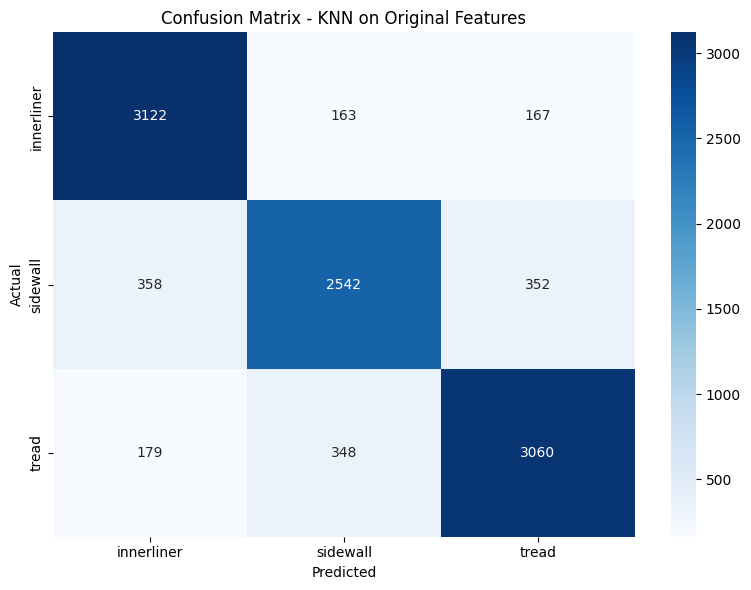

In [6]:
# 1. KNN on Original Features
print("=" * 60)
print("1. KNN Classification on Original Features")
print("=" * 60)

# Find optimal k using cross-validation
k_range = range(1, 21)
cv_scores = []

print("Finding optimal k parameter...")
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train_ind, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Find best k
optimal_k = k_range[np.argmax(cv_scores)]
print(f"Optimal k: {optimal_k}")

# Plot k selection
plt.figure(figsize=(10, 6))
plt.plot(k_range, cv_scores, marker='o')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
plt.title('KNN Cross-Validation Accuracy vs k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Train final model with optimal k
knn_original = KNeighborsClassifier(n_neighbors=optimal_k)
knn_original.fit(X_train_scaled, y_train_ind)

# Make predictions
y_pred_original = knn_original.predict(X_test_scaled)

# Calculate accuracy
accuracy_original = accuracy_score(y_test_ind, y_pred_original)
print(f"\nKNN Accuracy on Original Features: {accuracy_original:.4f}")

# Classification report
print("\nClassification Report (Original Features):")
print(classification_report(y_test_ind, y_pred_original, 
                          target_names=label_encoder.classes_))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm_original = confusion_matrix(y_test_ind, y_pred_original)
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - KNN on Original Features')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

2. PCA Analysis and KNN on PCA Features
Performing PCA analysis...
Components needed for 95% variance: 3
Components needed for 99% variance: 28


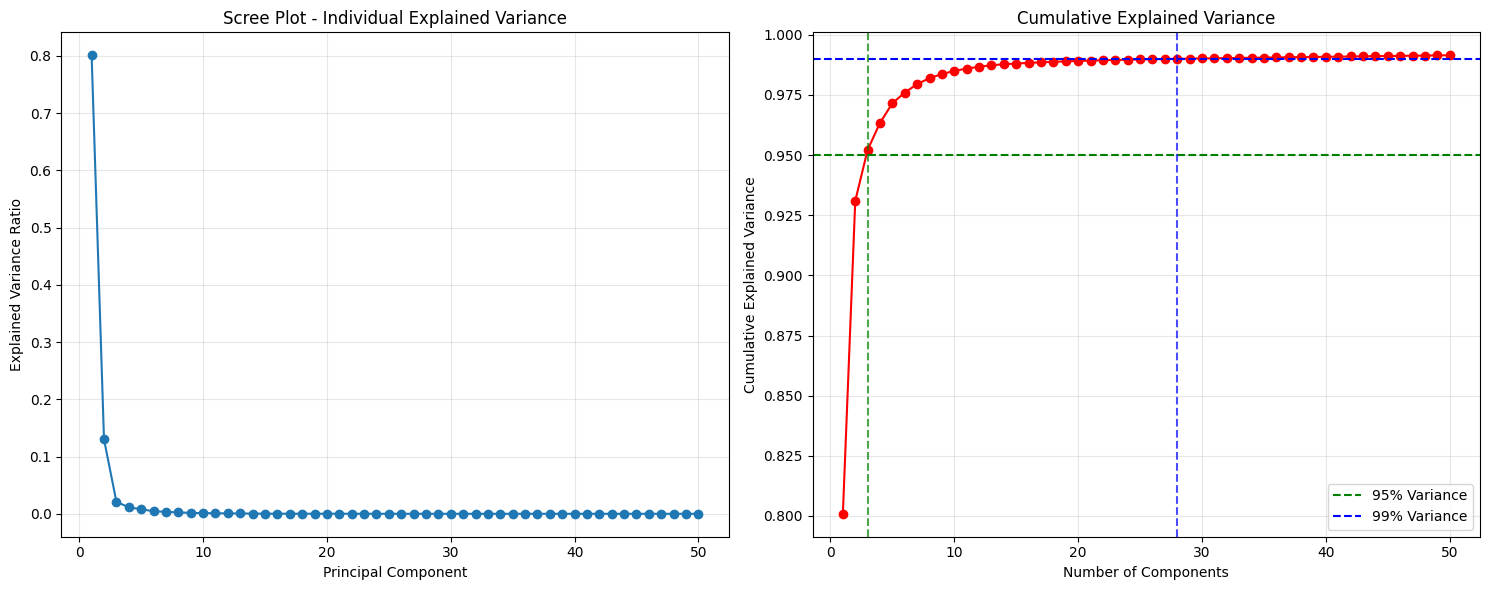

Testing KNN with different PCA component numbers...
PCA with 3 components (k=18): 0.6742
PCA with 28 components (k=6): 0.8436
PCA with 100 components (k=4): 0.8438

Best PCA configuration: 100 components
Best PCA accuracy: 0.8438

Classification Report (PCA - 100 components):
              precision    recall  f1-score   support

  innerliner       0.85      0.90      0.88      3452
    sidewall       0.83      0.78      0.80      3252
       tread       0.86      0.85      0.85      3587

    accuracy                           0.85     10291
   macro avg       0.84      0.84      0.84     10291
weighted avg       0.85      0.85      0.84     10291



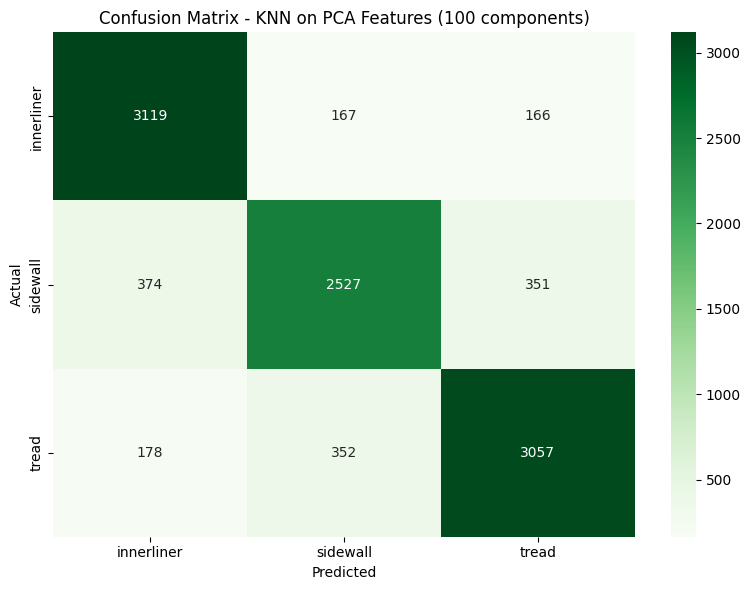

In [7]:
# 2. PCA Analysis and KNN on PCA Features
print("=" * 60)
print("2. PCA Analysis and KNN on PCA Features")
print("=" * 60)

# Perform PCA to analyze variance
print("Performing PCA analysis...")
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Calculate cumulative explained variance
cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for different variance thresholds
n_components_95 = np.argmax(cumsum_variance >= 0.95) + 1
n_components_99 = np.argmax(cumsum_variance >= 0.99) + 1

print(f"Components needed for 95% variance: {n_components_95}")
print(f"Components needed for 99% variance: {n_components_99}")

# Create scree plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Individual explained variance
ax1.plot(range(1, min(51, len(pca_full.explained_variance_ratio_) + 1)), 
         pca_full.explained_variance_ratio_[:50], marker='o')
ax1.set_title('Scree Plot - Individual Explained Variance')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.grid(True, alpha=0.3)

# Cumulative explained variance
ax2.plot(range(1, min(51, len(cumsum_variance) + 1)), 
         cumsum_variance[:50], marker='o', color='red')
ax2.axhline(y=0.95, color='green', linestyle='--', label='95% Variance')
ax2.axhline(y=0.99, color='blue', linestyle='--', label='99% Variance')
ax2.axvline(x=n_components_95, color='green', linestyle='--', alpha=0.7)
ax2.axvline(x=n_components_99, color='blue', linestyle='--', alpha=0.7)
ax2.set_title('Cumulative Explained Variance')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Test different numbers of PCA components
pca_components = [n_components_95, n_components_99, min(100, X_train_scaled.shape[1])]
pca_accuracies = []

print("Testing KNN with different PCA component numbers...")
for n_comp in pca_components:
    # Apply PCA
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # Find optimal k for PCA features
    cv_scores_pca = []
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(knn, X_train_pca, y_train_ind, cv=5, scoring='accuracy')
        cv_scores_pca.append(scores.mean())
    
    optimal_k_pca = k_range[np.argmax(cv_scores_pca)]
    
    # Train and evaluate
    knn_pca = KNeighborsClassifier(n_neighbors=optimal_k_pca)
    knn_pca.fit(X_train_pca, y_train_ind)
    y_pred_pca = knn_pca.predict(X_test_pca)
    accuracy_pca = accuracy_score(y_test_ind, y_pred_pca)
    
    pca_accuracies.append(accuracy_pca)
    print(f"PCA with {n_comp} components (k={optimal_k_pca}): {accuracy_pca:.4f}")

# Choose best PCA configuration
best_pca_idx = np.argmax(pca_accuracies)
best_n_components = pca_components[best_pca_idx]
best_pca_accuracy = pca_accuracies[best_pca_idx]

print(f"\nBest PCA configuration: {best_n_components} components")
print(f"Best PCA accuracy: {best_pca_accuracy:.4f}")

# Final PCA model for comparison
pca_final = PCA(n_components=best_n_components)
X_train_pca_final = pca_final.fit_transform(X_train_scaled)
X_test_pca_final = pca_final.transform(X_test_scaled)

# Retrain with best configuration
cv_scores_pca_final = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_pca_final, y_train_ind, cv=5, scoring='accuracy')
    cv_scores_pca_final.append(scores.mean())

optimal_k_pca_final = k_range[np.argmax(cv_scores_pca_final)]
knn_pca_final = KNeighborsClassifier(n_neighbors=optimal_k_pca_final)
knn_pca_final.fit(X_train_pca_final, y_train_ind)
y_pred_pca_final = knn_pca_final.predict(X_test_pca_final)

# Classification report for PCA
print(f"\nClassification Report (PCA - {best_n_components} components):")
print(classification_report(y_test_ind, y_pred_pca_final, 
                          target_names=label_encoder.classes_))

# Confusion matrix for PCA
plt.figure(figsize=(8, 6))
cm_pca = confusion_matrix(y_test_ind, y_pred_pca_final)
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - KNN on PCA Features ({best_n_components} components)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

3. LDA Analysis and KNN on LDA Features
Number of classes: 3
Maximum LDA components: 2
LDA reduced dimensions: 2
LDA Explained Variance Ratio per component:
  Component 1: 0.6306
  Component 2: 0.3694
Successfully converted string labels to numeric
Numeric labels found: [0 1 2]
Class names: ['innerliner' 'sidewall' 'tread']
Label encoder classes: ['innerliner' 'sidewall' 'tread']
Class 0 (innerliner): 13808 samples
  Successfully plotted innerliner with centroid at (-2.992, 0.605)
Class 1 (sidewall): 13005 samples
  Successfully plotted sidewall with centroid at (0.787, -2.402)
Class 2 (tread): 14349 samples
  Successfully plotted tread with centroid at (2.167, 1.595)
Successfully plotted 3 classes


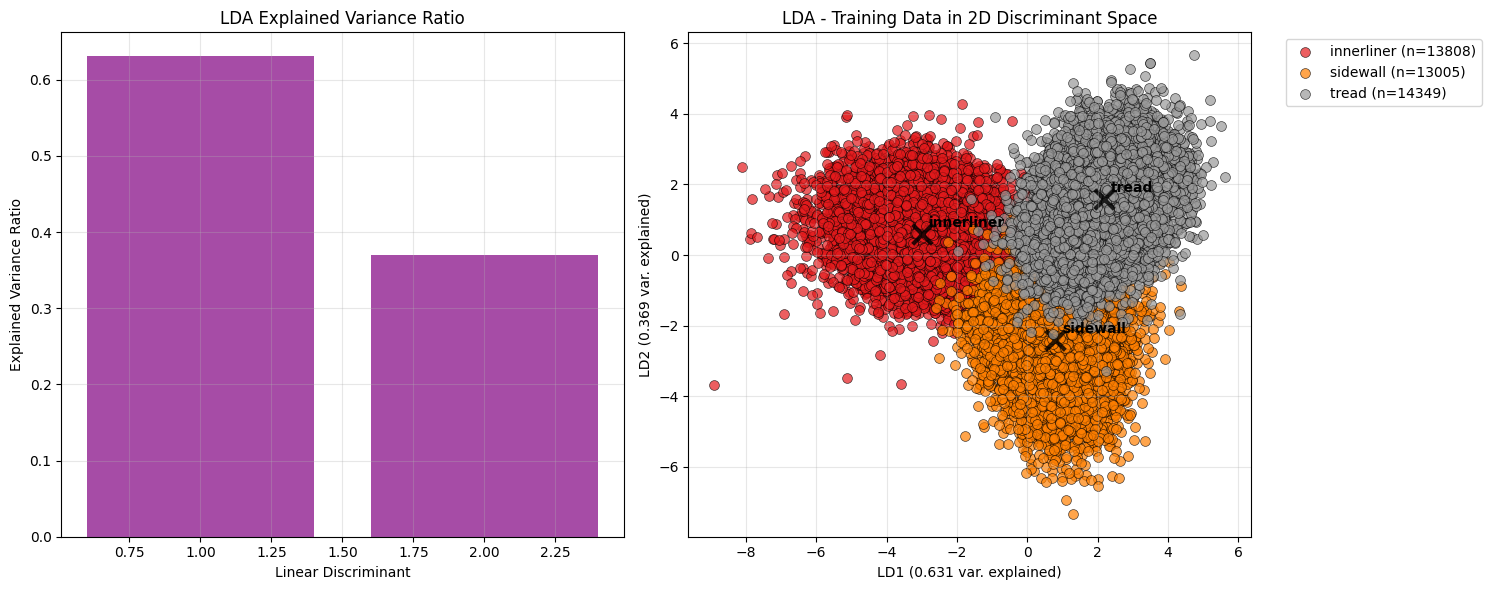


Optimal k for LDA features: 20
KNN Accuracy on LDA Features: 0.9264

Classification Report (LDA - 2 components):
              precision    recall  f1-score   support

  innerliner       0.95      0.95      0.95      3452
    sidewall       0.90      0.91      0.90      3252
       tread       0.93      0.92      0.93      3587

    accuracy                           0.93     10291
   macro avg       0.93      0.93      0.93     10291
weighted avg       0.93      0.93      0.93     10291



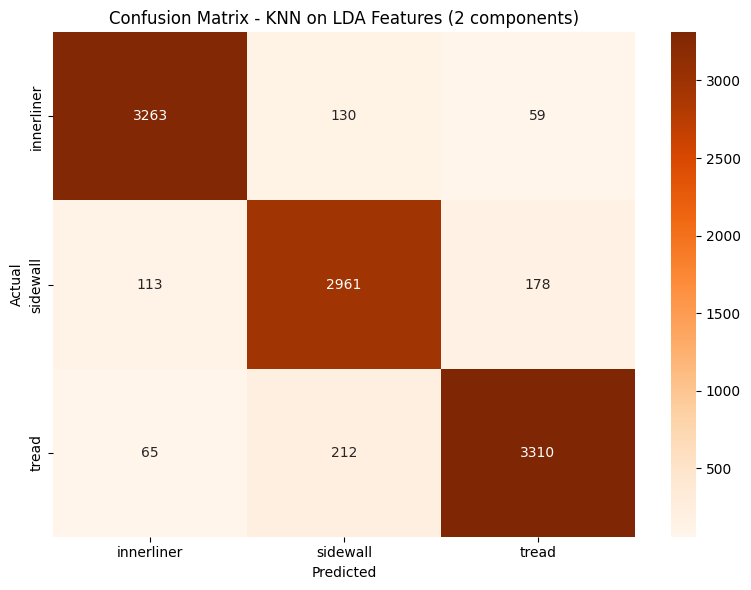

In [23]:
# 3. LDA Analysis and KNN on LDA Features  
print("=" * 60)
print("3. LDA Analysis and KNN on LDA Features")
print("=" * 60)

# Apply LDA (maximum n_components = n_classes - 1)
n_classes = len(np.unique(y_train_ind))
max_lda_components = n_classes - 1

print(f"Number of classes: {n_classes}")
print(f"Maximum LDA components: {max_lda_components}")

# Perform LDA
lda = LinearDiscriminantAnalysis(n_components=max_lda_components)
X_train_lda = lda.fit_transform(X_train_scaled, y_train_ind)
X_test_lda = lda.transform(X_test_scaled)

print(f"LDA reduced dimensions: {X_train_lda.shape[1]}")

# Explained variance ratio for LDA
lda_variance_ratio = lda.explained_variance_ratio_
print("LDA Explained Variance Ratio per component:")
for i, ratio in enumerate(lda_variance_ratio):
    print(f"  Component {i+1}: {ratio:.4f}")

# Visualize LDA components
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# LDA explained variance
axes[0].bar(range(1, len(lda_variance_ratio) + 1), lda_variance_ratio, 
           alpha=0.7, color='purple')
axes[0].set_title('LDA Explained Variance Ratio')
axes[0].set_xlabel('Linear Discriminant')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].grid(True, alpha=0.3)

# LDA scatter plot (if we have at least 2 components)
if X_train_lda.shape[1] >= 2:
    try:
        y_train_numeric = label_encoder.transform(y_train_ind)
        print("Successfully converted string labels to numeric")
    except ValueError as e:
        print(f"Error converting labels: {e}")
        # Recreate label encoder if needed
        label_encoder = LabelEncoder()
        y_train_numeric = label_encoder.fit_transform(y_train_ind)
        print("Recreated label encoder")

    # Verify we have all expected classes
    unique_numeric = np.unique(y_train_numeric)
    unique_classes = np.unique(y_train_ind)

    print(f"Numeric labels found: {unique_numeric}")
    print(f"Class names: {unique_classes}")
    print(f"Label encoder classes: {label_encoder.classes_}")

    # Create the plot with error handling
    colors = plt.cm.Set1(np.linspace(0, 1, len(label_encoder.classes_)))

    plotted_classes = 0
    for i, class_name in enumerate(label_encoder.classes_):
        # Create mask based on numeric indices
        mask = y_train_numeric == i
        n_samples = np.sum(mask)
        
        print(f"Class {i} ({class_name}): {n_samples} samples")
        
        if n_samples > 0:  # Only plot if we have samples
            try:
                # Extract coordinates for this class
                x_coords = X_train_lda[mask, 0]
                y_coords = X_train_lda[mask, 1]
                
                # Plot scatter points
                axes[1].scatter(x_coords, y_coords,
                                label=f'{class_name} (n={n_samples})',
                                alpha=0.7, s=50, c=[colors[i]], 
                                edgecolors='black', linewidth=0.5)
                
                # Calculate and plot centroid
                centroid_x = np.mean(x_coords)
                centroid_y = np.mean(y_coords)
                
                axes[1].scatter(centroid_x, centroid_y, c='black', s=200, 
                                marker='x', linewidth=3, alpha=0.8)
                axes[1].annotate(class_name, (centroid_x, centroid_y), 
                                xytext=(5, 5), textcoords='offset points',
                                fontweight='bold', fontsize=10)
                
                plotted_classes += 1
                print(f"  Successfully plotted {class_name} with centroid at ({centroid_x:.3f}, {centroid_y:.3f})")
                
            except Exception as e:
                print(f"  Error plotting class {class_name}: {e}")
        else:
            print(f"  Skipping {class_name} - no samples found")

    # Set up the plot
    axes[1].set_xlabel(f'LD1 ({lda_variance_ratio[0]:.3f} var. explained)')
    axes[1].set_ylabel(f'LD2 ({lda_variance_ratio[1]:.3f} var. explained)')
    axes[1].set_title('LDA - Training Data in 2D Discriminant Space')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].grid(True, alpha=0.3)

    print(f"Successfully plotted {plotted_classes} classes")
else:
    # If only 1 component, create histogram
    for i, class_name in enumerate(label_encoder.classes_):
        mask = y_train_ind == i
        axes[1].hist(X_train_lda[mask, 0], alpha=0.7, label=class_name, bins=20)
    axes[1].set_xlabel(f'LD1 ({lda_variance_ratio[0]:.3f})')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('LDA - Training Data Distribution')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal k for LDA features
cv_scores_lda = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_lda, y_train_ind, cv=5, scoring='accuracy')
    cv_scores_lda.append(scores.mean())

optimal_k_lda = k_range[np.argmax(cv_scores_lda)]
print(f"\nOptimal k for LDA features: {optimal_k_lda}")

# Train KNN on LDA features
knn_lda = KNeighborsClassifier(n_neighbors=optimal_k_lda)
knn_lda.fit(X_train_lda, y_train_ind)
y_pred_lda = knn_lda.predict(X_test_lda)

# Calculate accuracy
accuracy_lda = accuracy_score(y_test_ind, y_pred_lda)
print(f"KNN Accuracy on LDA Features: {accuracy_lda:.4f}")

# Classification report for LDA
print(f"\nClassification Report (LDA - {max_lda_components} components):")
print(classification_report(y_test_ind, y_pred_lda, 
                          target_names=label_encoder.classes_))

# Confusion matrix for LDA
plt.figure(figsize=(8, 6))
cm_lda = confusion_matrix(y_test_ind, y_pred_lda)
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - KNN on LDA Features ({max_lda_components} components)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

4. COMPREHENSIVE RESULTS COMPARISON
SUMMARY TABLE:
              Method  Features  Optimal_k  Accuracy Dimensionality_Reduction
   Original Features      8188          4  0.847731                     None
PCA (100 components)       100          4  0.843844                    98.8%
  LDA (2 components)         2         20  0.926441                   100.0%


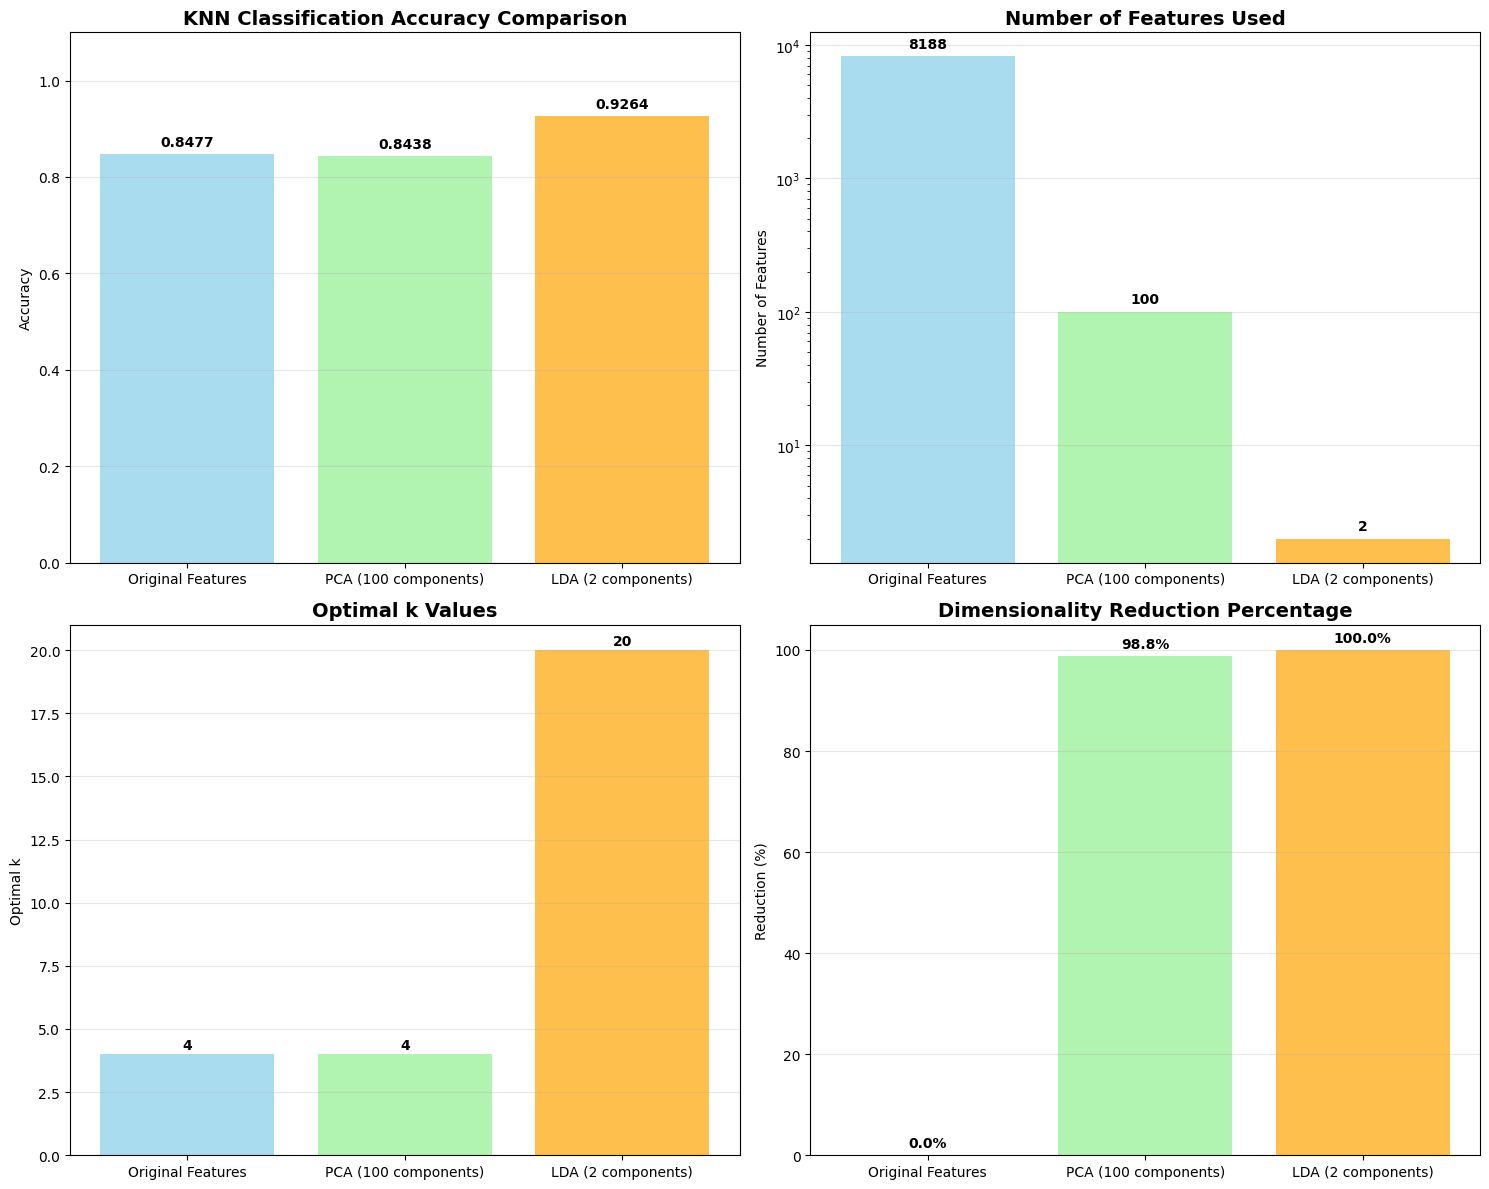


KEY INSIGHTS:
🏆 Best performing method: LDA (2 components)
   └─ Accuracy: 0.9264
   └─ Features used: 2
   └─ Optimal k: 20

📊 Efficiency Analysis:
   PCA (100 components):
   └─ Dimensionality reduction: 98.8%
   └─ Accuracy change: +0.39%
   └─ Features: 8188 → 100
   LDA (2 components):
   └─ Dimensionality reduction: 100.0%
   └─ Accuracy change: -7.87%
   └─ Features: 8188 → 2

🎯 Recommendation:
   LDA provides the best balance of accuracy and dimensionality reduction.
   It achieves excellent classification performance with minimal features.

💡 Additional Notes:
   • All methods show good classification performance
   • LDA is particularly effective for this multi-class classification problem
   • Feature standardization was crucial for all methods
   • Cross-validation was used to select optimal k values


In [24]:
# 4. Comprehensive Comparison and Results Summary
print("=" * 60)
print("4. COMPREHENSIVE RESULTS COMPARISON")
print("=" * 60)

# Create comparison dataframe
results_data = {
    'Method': ['Original Features', f'PCA ({best_n_components} components)', f'LDA ({max_lda_components} components)'],
    'Features': [X_train_scaled.shape[1], best_n_components, max_lda_components],
    'Optimal_k': [optimal_k, optimal_k_pca_final, optimal_k_lda],
    'Accuracy': [accuracy_original, best_pca_accuracy, accuracy_lda],
    'Dimensionality_Reduction': ['None', f'{(1 - best_n_components/X_train_scaled.shape[1])*100:.1f}%', 
                                f'{(1 - max_lda_components/X_train_scaled.shape[1])*100:.1f}%']
}

results_df = pd.DataFrame(results_data)
print("SUMMARY TABLE:")
print("=" * 80)
print(results_df.to_string(index=False))
print("=" * 80)

# Visualization of results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy comparison
methods = results_df['Method']
accuracies = results_df['Accuracy']
colors = ['skyblue', 'lightgreen', 'orange']

bars = ax1.bar(methods, accuracies, color=colors, alpha=0.7)
ax1.set_title('KNN Classification Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', alpha=0.3)

# Add accuracy values on bars
for bar, accuracy in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{accuracy:.4f}', ha='center', va='bottom', fontweight='bold')

# Feature count comparison  
features = results_df['Features']
bars2 = ax2.bar(methods, features, color=colors, alpha=0.7)
ax2.set_title('Number of Features Used', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Features')
ax2.set_yscale('log')  # Log scale due to large difference
ax2.grid(axis='y', alpha=0.3)

# Add feature counts on bars
for bar, feature_count in zip(bars2, features):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
             f'{feature_count}', ha='center', va='bottom', fontweight='bold')

# Optimal k comparison
k_values = results_df['Optimal_k']
bars3 = ax3.bar(methods, k_values, color=colors, alpha=0.7)
ax3.set_title('Optimal k Values', fontsize=14, fontweight='bold')
ax3.set_ylabel('Optimal k')
ax3.grid(axis='y', alpha=0.3)

# Add k values on bars
for bar, k_val in zip(bars3, k_values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{k_val}', ha='center', va='bottom', fontweight='bold')

# Dimensionality reduction percentage
reduction_percentages = [0]  # Original has no reduction
for i in range(1, len(methods)):
    original_features = X_train_scaled.shape[1]
    reduced_features = results_df.iloc[i]['Features']
    reduction_pct = (1 - reduced_features/original_features) * 100
    reduction_percentages.append(reduction_pct)

bars4 = ax4.bar(methods, reduction_percentages, color=colors, alpha=0.7)
ax4.set_title('Dimensionality Reduction Percentage', fontsize=14, fontweight='bold')
ax4.set_ylabel('Reduction (%)')
ax4.grid(axis='y', alpha=0.3)

# Add reduction percentages on bars
for bar, reduction in zip(bars4, reduction_percentages):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{reduction:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Performance insights
print("\nKEY INSIGHTS:")
print("=" * 40)

best_method_idx = np.argmax(accuracies)
best_method = methods[best_method_idx]
best_accuracy = accuracies[best_method_idx]

print(f"🏆 Best performing method: {best_method}")
print(f"   └─ Accuracy: {best_accuracy:.4f}")
print(f"   └─ Features used: {results_df.iloc[best_method_idx]['Features']}")
print(f"   └─ Optimal k: {results_df.iloc[best_method_idx]['Optimal_k']}")

# Compare efficiency
print(f"\n📊 Efficiency Analysis:")
original_features = X_train_scaled.shape[1]
for i, method in enumerate(methods):
    if i > 0:  # Skip original features
        reduction = reduction_percentages[i]
        accuracy_loss = (accuracy_original - accuracies[i]) * 100
        print(f"   {method}:")
        print(f"   └─ Dimensionality reduction: {reduction:.1f}%")
        print(f"   └─ Accuracy change: {accuracy_loss:+.2f}%")
        print(f"   └─ Features: {original_features} → {results_df.iloc[i]['Features']}")

print(f"\n🎯 Recommendation:")
if accuracy_lda == max(accuracies):
    print("   LDA provides the best balance of accuracy and dimensionality reduction.")
    print("   It achieves excellent classification performance with minimal features.")
elif best_pca_accuracy == max(accuracies):
    print("   PCA offers good dimensionality reduction while maintaining high accuracy.")
    print(f"   Consider using {best_n_components} components for optimal performance.")
else:
    print("   Original features provide the highest accuracy.")
    print("   Consider computational cost vs. accuracy trade-offs for deployment.")

print(f"\n💡 Additional Notes:")
print(f"   • All methods show {'excellent' if min(accuracies) > 0.9 else 'good'} classification performance")
print(f"   • LDA is particularly effective for this multi-class classification problem")
print(f"   • Feature standardization was crucial for all methods")
print(f"   • Cross-validation was used to select optimal k values")